In [1]:
library(Seurat)
library(harmony)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(dplyr)

source('../R_function/knn_function.R')
source('../R_function/calculate_function.R')
source('../R_function/ST_plot.R')
source('../R_function/plot_function.R')
source('../R_function/MultiSpecies.R')

Attaching SeuratObject

Loading required package: Rcpp

Loading required package: grid

ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in publi

In [1]:
go_og_df <- read.csv('Analysis/OG_mous_GO_annotation.csv',row.names = 1)
kegg_og_df <- read.csv('Analysis/OG_mous_KEGG_annotation.csv',row.names = 1)
go_og_df$term <- paste0(go_og_df$term,'#',go_og_df$ont)

In [3]:
go_database_term_list <- unique(go_og_df$term)
go_database_gene_list <- sapply(go_database_term_list,function(x){return(paste0(go_og_df[go_og_df$term==x,'OG'],collapse = ','))})

In [4]:
kegg_database_term_list <- unique(kegg_og_df$term)
kegg_database_gene_list <- sapply(kegg_database_term_list,function(x){return(paste0(kegg_og_df[kegg_og_df$term==x,'OG'],collapse = ','))})

In [5]:
all_df <- read.csv('Analysis/All_gene_info_Mfuzz.csv',row.names = 1)
species_order <- c('marm','mous','bird','turt','axol')

Pr_cluster_name <- unique(all_df[all_df$Pr_cluster!='Other','Pr_cluster'])
Pr_cluster_list <- lapply(Pr_cluster_name,function(x){
    vec_tmp <- rownames(all_df[all_df$Pr_cluster==x,])
    return(vec_tmp)
})
names(Pr_cluster_list) <- Pr_cluster_name

Al_cluster_name <- unique(all_df[all_df$Al_cluster!='Other','Al_cluster'])
Al_cluster_list <- lapply(Al_cluster_name,function(x){
    vec_tmp <- rownames(all_df[all_df$Al_cluster==x,])
    return(vec_tmp)
})
names(Al_cluster_list) <- Al_cluster_name

Cluster_list <- append(Pr_cluster_list, Al_cluster_list)

In [8]:
shared_Cluster_list <- Cluster_list[c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal')]
GO_result <- dplyr::bind_rows(lapply(names(shared_Cluster_list),function(x){
    df_tmp <- Enrichment_myself(shared_Cluster_list[[x]], go_database_term_list, go_database_gene_list, background = NULL)
    df_tmp$cluster <- x
    return(df_tmp)
}))

In [9]:
GO_result <- GO_result[grep('#BP',GO_result$Term),]
GO_result$FDR <- -log(GO_result$pvalue)
GO_result_thre <- GO_result[GO_result$pvalue<0.05,]
GO_result_thre$Size <- sapply(strsplit(GO_result_thre$GeneRatio, "/"), function(x) {as.numeric(x[1]) / as.numeric(x[2])})

In [32]:
GO_result_order <- reshape2::acast(GO_result_thre,cluster~Term,value.var = 'Size',fill=0)
GO_result_order <- order_matrix(GO_result_order,row_order = c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal'))

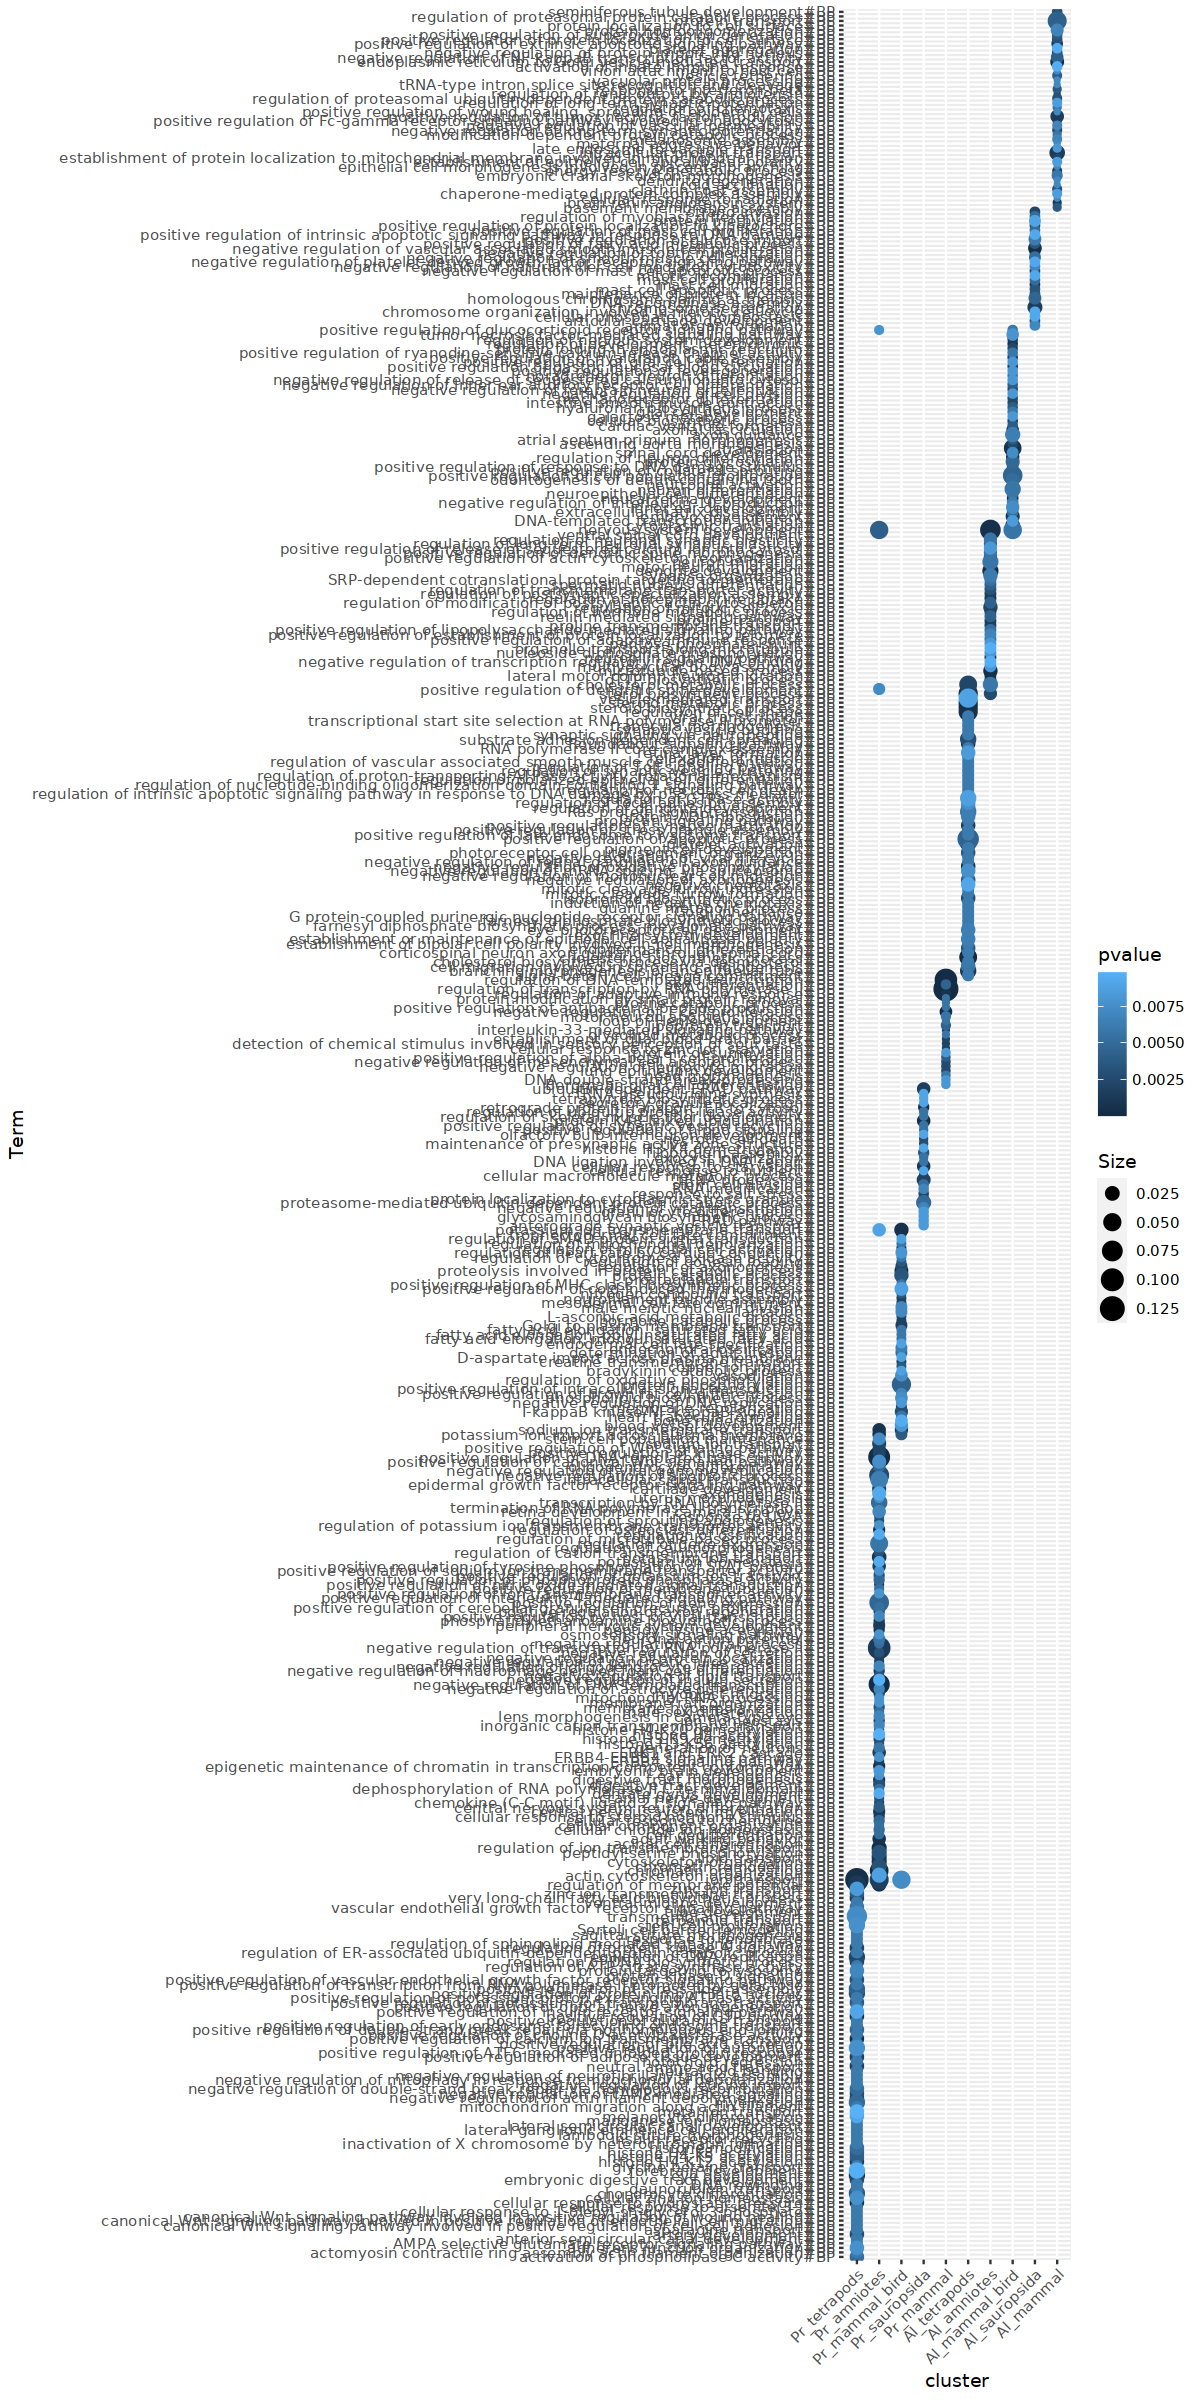

In [33]:
GO_result_thre$cluster <- factor(GO_result_thre$cluster, levels = c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal'))
GO_result_thre$Term <- factor(GO_result_thre$Term, levels = GO_result_order$var)

options(repr.plot.width=10,repr.plot.height=20)
ggplot()+
geom_point(data=GO_result_thre,aes(x=cluster,y=Term,color=pvalue,size=Size))+
#theme_test()+
theme(axis.text.x = element_text(angle = 45,hjust = 1,vjust = 1))

In [10]:
shared_Cluster_list <- Cluster_list[c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal')]
KEGG_result <- dplyr::bind_rows(lapply(names(shared_Cluster_list),function(x){
    df_tmp <- Enrichment_myself(shared_Cluster_list[[x]], kegg_database_term_list, kegg_database_gene_list, background = unique(go_og_df$OG))
    df_tmp$cluster <- x
    return(df_tmp)
}))
KEGG_result$FDR <- -log(KEGG_result$pvalue)
KEGG_result_thre <- KEGG_result[KEGG_result$pvalue<0.05,]
KEGG_result_thre$Size <- sapply(strsplit(KEGG_result_thre$GeneRatio, "/"), function(x) {as.numeric(x[1]) / as.numeric(x[2])})

In [10]:
KEGG_result_order <- reshape2::acast(KEGG_result_thre,cluster~Term,value.var = 'Size',fill=0)
KEGG_result_order <- order_matrix(KEGG_result_order,row_order = c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal'))

In [481]:
write.csv(KEGG_result_thre,'Analysis/KEGG_result.csv')

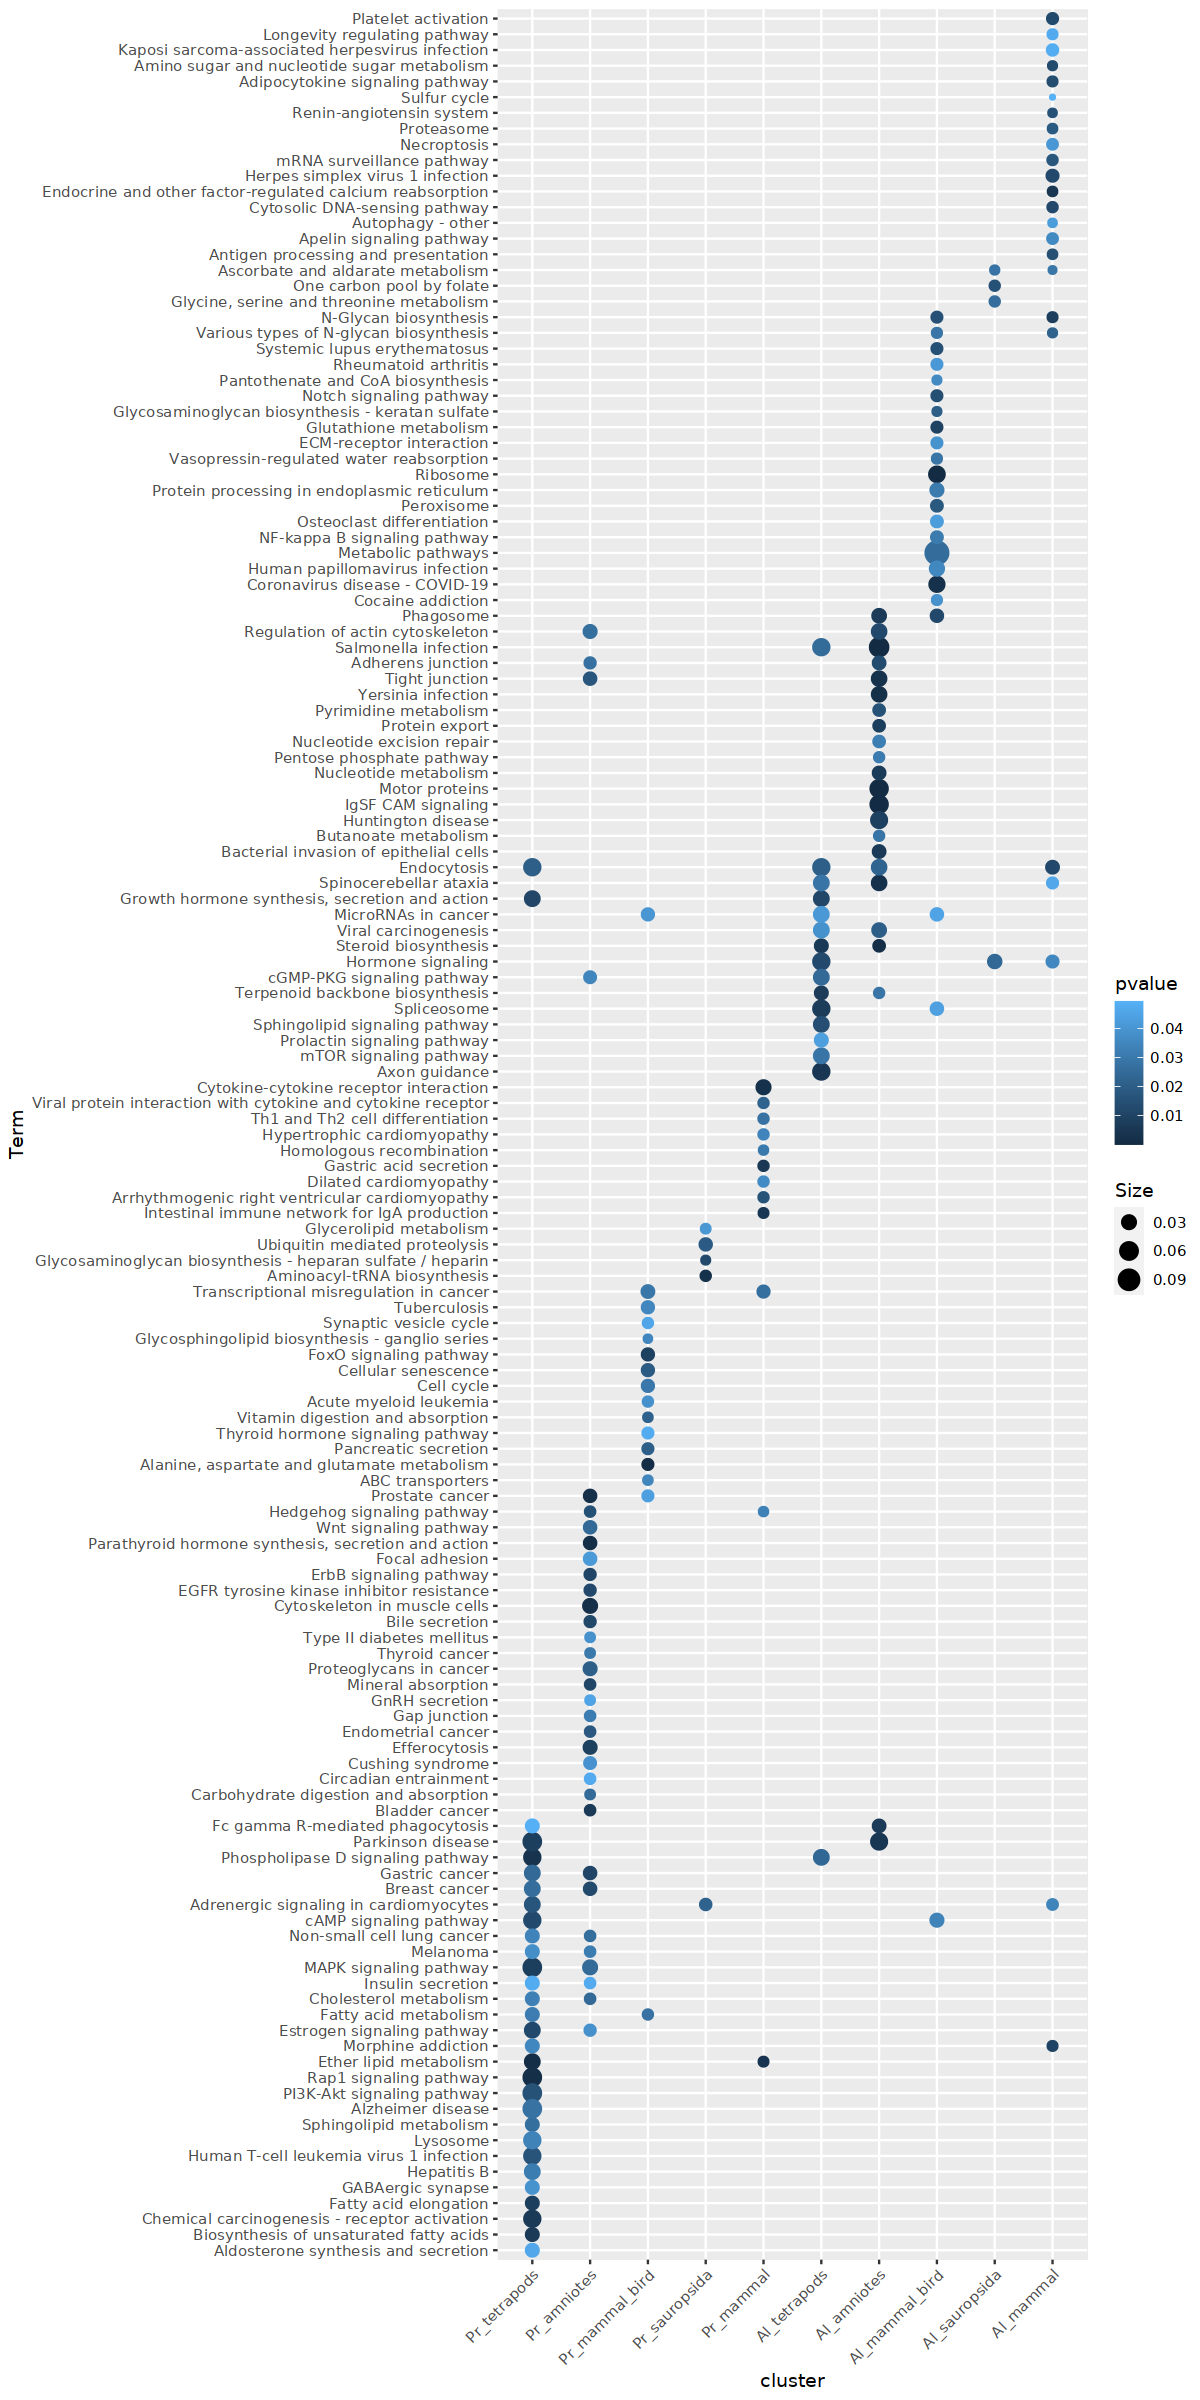

In [11]:
KEGG_result_thre$cluster <- factor(KEGG_result_thre$cluster, levels = c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_sauropsida','Pr_mammal','Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_sauropsida','Al_mammal'))
KEGG_result_thre$Term <- factor(KEGG_result_thre$Term, levels = KEGG_result_order$var)

options(repr.plot.width=10,repr.plot.height=20)
ggplot()+
geom_point(data=KEGG_result_thre,aes(x=cluster,y=Term,color=pvalue,size=Size))+
#theme_test()+
theme(axis.text.x = element_text(angle = 45,hjust = 1,vjust = 1))

In [97]:
KEGG_result_thre[ KEGG_result_thre$Term%in%c('Axon guidance','Wnt signaling pathway','Notch signaling pathway',
                                             'Hedgehog signaling pathway','MAPK signaling pathway','Ras signaling pathway','PI3K-Akt signaling pathway'),]

,Term,Count,GeneRatio,BgRatio,pvalue,p.adjust,Hit_OG,cluster,FDR,Size
,<fct>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<dbl>
6,MAPK signaling pathway,5,5/85,207/14110,0.008227835,0.1838807,"OG0012780,OG0002261,OG0011800,OG0010058,OG0008345",Pr_tetrapods,4.800232,0.058823529
12,PI3K-Akt signaling pathway,5,5/85,244/14110,0.015887878,0.2139458,"OG0012780,OG0002969,OG0003983,OG0010058,OG0001753",Pr_tetrapods,4.142199,0.058823529
188,Hedgehog signaling pathway,4,4/332,41/14110,0.015372153,0.3210085,"OG0006701,OG0007335,OG0007635,OG0001692",Pr_amniotes,4.175198,0.012048193
192,Wnt signaling pathway,7,7/332,121/14110,0.024223977,0.3210085,"OG0001472,OG0000462,OG0001442,OG0008468,OG0002913,OG0007635,OG0010547",Pr_amniotes,3.720412,0.021084337
194,MAPK signaling pathway,10,10/332,207/14110,0.024837112,0.3210085,"OG0004289,OG0000558,OG0004066,OG0000297,OG0008067,OG0000526,OG0002048,OG0011205,OG0011615,OG0001473",Pr_amniotes,3.695416,0.030120482
964,Hedgehog signaling pathway,5,5/622,41/14110,0.033140932,0.8774877,"OG0000995,OG0011924,OG0011284,OG0011657,OG0002631",Pr_mammal,3.406986,0.008038585
1244,Axon guidance,4,4/85,113/14110,0.004799342,0.2972009,"OG0000791,OG0003602,OG0000266,OG0000910",Al_tetrapods,5.339277,0.047058824
1582,Notch signaling pathway,4,4/287,46/14110,0.013997033,0.4917310,"OG0003227,OG0002018,OG0003672,OG0000472",Al_mammal_bird,4.268910,0.013937282


In [142]:
GO_result_thre[ GO_result_thre$Term%in%c('nervous system development#BP','neurogenesis#BP','axonogenesis#BP','axon extension#BP',
'axon guidance#BP','regulation of axonogenesis#BP','synaptogenesis#BP','synapse organization#BP','regulation of synaptic plasticity#BP',
'anterograde synaptic vesicle transport#BP','regulation of postsynaptic neurotransmitter receptor internalization#BP',
'neural circuit plasticity#BP','establishment of neuron projection pattern#BP','maintenance of neuron projection pattern#BP',
                                        'regulation of postsynaptic membrane neurotransmitter receptor levels#BP'),]

,Term,Count,GeneRatio,BgRatio,pvalue,p.adjust,Hit_OG,cluster,FDR,Size
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1502,nervous system development#BP,17,17/332,352/14110,0.004147382,0.13451602,"OG0011361,OG0004871,OG0004894,OG0000660,OG0000555,OG0000297,OG0005600,OG0001487,OG0001735,OG0007902,OG0010813,OG0009757,OG0005960,OG0011615,OG0004792,OG0001184,OG0005901",Pr_amniotes,5.485278,0.051204819
1559,axonogenesis#BP,7,7/332,100/14110,0.009279615,0.18056723,"OG0002122,OG0006680,OG0001054,OG0000526,OG0011630,OG0001184,OG0013039",Pr_amniotes,4.679935,0.021084337
4857,regulation of axonogenesis#BP,4,4/353,23/14110,0.002339929,0.23532050,"OG0000291,OG0000231,OG0012953,OG0010068",Pr_mammal_bird,6.057635,0.011331445
7934,anterograde synaptic vesicle transport#BP,3,3/438,14/14110,0.008378186,0.34735790,"OG0009653,OG0002801,OG0009556",Pr_sauropsida,4.782124,0.006849315
8195,regulation of postsynaptic neurotransmitter receptor internalization#BP,3,3/438,23/14110,0.033190174,0.36651123,"OG0003273,OG0013347,OG0001964",Pr_sauropsida,3.405501,0.006849315
15750,regulation of synaptic plasticity#BP,2,2/85,56/14110,0.044784664,0.15323745,"OG0009524,OG0006829",Al_tetrapods,3.105890,0.023529412
16609,nervous system development#BP,13,13/178,352/14110,0.000529626,0.06109392,"OG0002780,OG0011326,OG0002369,OG0000163,OG0007904,OG0010918,OG0006117,OG0005200,OG0002345,OG0001381,OG0000655,OG0007600,OG0005963",Al_amniotes,7.543339,0.073033708
16656,synapse organization#BP,4,4/178,58/14110,0.006115101,0.13300184,"OG0001695,OG0001055,OG0002807,OG0006117",Al_amniotes,5.096994,0.022471910
16904,axon guidance#BP,5,5/178,135/14110,0.028189817,0.17718023,"OG0011326,OG0006602,OG0002369,OG0000163,OG0002345",Al_amniotes,3.568794,0.028089888


pdf 
  2

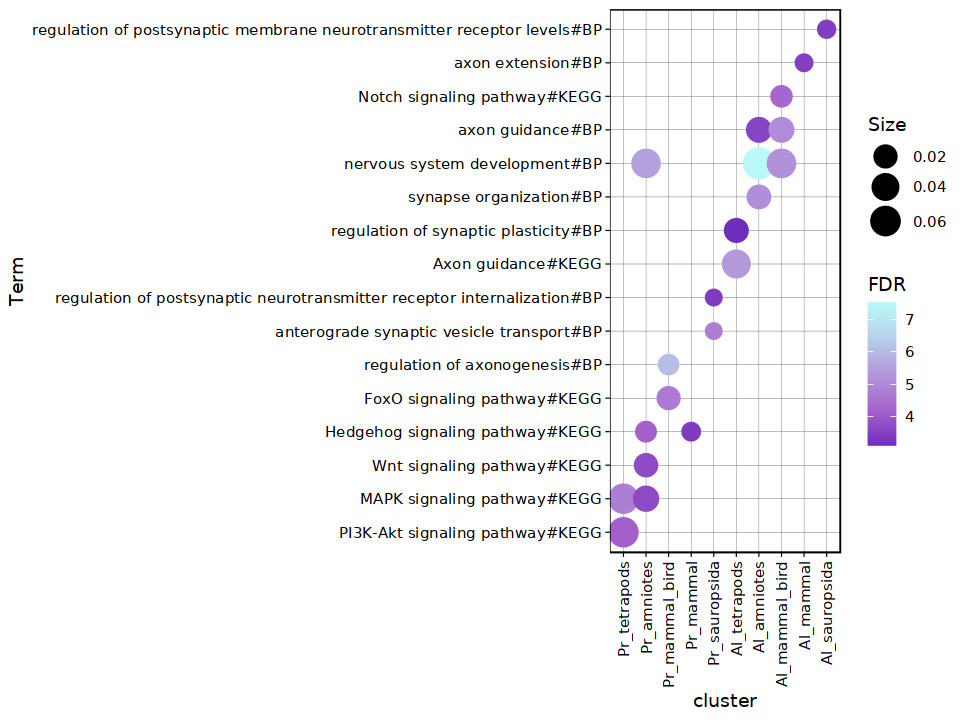

In [11]:
use_GO_Kegg <- c(
    #Pr_tetrapods
    'PI3K-Akt signaling pathway#KEGG',
    #Pr_tetrapods, Pr_amniotes
    'MAPK signaling pathway#KEGG',
    #Pr_amniotes
    'Wnt signaling pathway#KEGG',
    #Pr_amniotes,Pr_mammal
    'Hedgehog signaling pathway#KEGG',
    #Pr_mammal_bird
    'FoxO signaling pathway#KEGG','regulation of axonogenesis#BP',
    #Pr_sauropsida
    'anterograde synaptic vesicle transport#BP','regulation of postsynaptic neurotransmitter receptor internalization#BP',
    #Al_tetrapods
    'Axon guidance#KEGG','regulation of synaptic plasticity#BP',
    #Al_amniotes
    'synapse organization#BP',
    #Al_amniotes, Al_mammal_bird
    'nervous system development#BP','axon guidance#BP',
    #Al_mammal_bird
    'Notch signaling pathway#KEGG',
    #Al_mammal
    'axon extension#BP',
    #Al_sauropsida
    'regulation of postsynaptic membrane neurotransmitter receptor levels#BP'
)
KEGG_result_choice <- KEGG_result_thre[ paste0(KEGG_result_thre$Term,'#KEGG')%in%use_GO_Kegg,]
KEGG_result_choice$Term <- paste0(KEGG_result_choice$Term,'#KEGG')
GO_result_choice <- GO_result_thre[GO_result_thre$Term%in%use_GO_Kegg,]
df_result_choice <- rbind(KEGG_result_choice[,c('Term','Count','GeneRatio','BgRatio','pvalue','p.adjust','FDR','cluster','Size','Hit_OG')],
                          GO_result_choice[,c('Term','Count','GeneRatio','BgRatio','pvalue','p.adjust','FDR','cluster','Size','Hit_OG')])
df_result_choice$cluster <- factor(df_result_choice$cluster, levels = c('Pr_tetrapods','Pr_amniotes','Pr_mammal_bird','Pr_mammal','Pr_sauropsida',
                                                                        'Al_tetrapods','Al_amniotes','Al_mammal_bird','Al_mammal','Al_sauropsida'))
df_result_choice$Term <- factor(df_result_choice$Term, levels = use_GO_Kegg)

options(repr.plot.width=8,repr.plot.height=6)
p <- ggplot()+
geom_point(data=df_result_choice,aes(x=cluster,y=Term,color=FDR,size=Size))+
#theme_test()+
theme_linedraw()+
scale_color_gradientn(colours = c("#6f2dbd","#a663cc","#b298dc","#b8d0eb","#b9faf8"))+
theme(axis.text.x = element_text(angle = 90,hjust = 1,vjust = 0.5))+
scale_size(range = c(4,8))
p
pdf(paste0('/mnt/gandan/huangzhi/jupyter/Multispecies/Plot/Mfuzz_cluster_KEGG_result.pdf'),width=8,height=6)
p
dev.off()

In [13]:
write.csv(df_result_choice,'Analysis/PrAl_KEGGGO_result.csv')

In [243]:
for(i in 1:nrow(df_result_choice)){
    OG_use <- strsplit(df_result_choice[i,'Hit_OG'],',')[[1]]
    Term <- df_result_choice[i,'Term']
    print(paste0(Term,': ',paste0(all_df[OG_use,]$Marmoset.pep,collapse = ' | ')))
}

[1] "MAPK signaling pathway#KEGG: FGF9 | ELK3, ELK4 | CACNB4 | NRTN | MAP3K1"
[1] "PI3K-Akt signaling pathway#KEGG: FGF9 | ATF6, ATF6B | PIK3CA | NRTN | LPAR1, LPAR2"
[1] "Hedgehog signaling pathway#KEGG: SMO | HHATL | CSNK1A1 | MGRN1, RNF157"
[1] "Wnt signaling pathway#KEGG: CREBBP, EP300 | CHD6, CHD7, CHD8, CHD9 | DAAM1, DAAM2 | LEF1 | SFRP1, SFRP5 | CSNK1A1 | NFATC2"
[1] "MAPK signaling pathway#KEGG: TNFRSF1A | CACNA1G, CACNA1H, CACNA1I, LOC100413607, LOC118147193 | BRAF, LOC108593776 | EGFR, ERBB2, ERBB3, ERBB4, LOC103794733 | DUSP10 | FGFR1, FGFR2, FGFR3, FGFR4 | DUSP1, DUSP4 | EGF | RET | GNA12, GNA13"
[1] "FoxO signaling pathway#KEGG: ATM | LOC100396301, LOC100415620 | TGFBR2 | SOD2 | SETD7 | RBL1, RBL2 | KLF2"
[1] "Hedgehog signaling pathway#KEGG: DHH, IHH, SHH | HHAT | EVC2 | SUFU | SPOP, SPOPL"
[1] "Axon guidance#KEGG: EFNB1, EFNB2, EFNB3 | PLXNC1 | LOC100404129, LOC108593039, RHOA, RHOB, RHOC, RHOD, RHOF | SLIT1, SLIT2, SLIT3"
[1] "Notch signaling pathway#KEGG: HDAC1, HDAC2 

In [14]:
inter_df <- read.csv('Analysis/Mammal_Association_Gene_Cluster.csv',sep=',',row.names = 1)

In [16]:
MammalBird_KEGG <- Enrichment_myself(rownames(inter_df)[inter_df$anno=='BirdAs'], kegg_database_term_list, kegg_database_gene_list, background = unique(go_og_df$OG))
MammalBird_GO <- Enrichment_myself(rownames(inter_df)[inter_df$anno=='BirdAs'], go_database_term_list, go_database_gene_list, background = unique(go_og_df$OG))

In [17]:
MammalBird_GO$Description <- sapply(MammalBird_GO$Term,function(x){return(strsplit(x,'#')[[1]][1])})
MammalBird_GO$ONT <- sapply(MammalBird_GO$Term,function(x){return(strsplit(x,'#')[[1]][2])})

In [18]:
MammalBird_KEGG$Description <- MammalBird_KEGG$Term

In [7]:
source('../R_function/Run_GO_KEGG.R')

In [19]:
df_result_choice <- MammalBird_GO[MammalBird_GO$Description%in%c('synapse',
                                      'regulation of short-term neuronal synaptic plasticity',
                                      'neuron differentiation',
                                      'vesicle-mediated transport',
                                      'regulation of postsynaptic neurotransmitter receptor activity',
                                      'regulation of synapse organization'),]
for(i in 1:nrow(df_result_choice)){
    OG_use <- strsplit(df_result_choice[i,'Hit_OG'],',')[[1]]
    Term <- df_result_choice[i,'Term']
    print(paste0(Term,': ',paste0(all_df[OG_use,]$Marmoset.pep,collapse = ' | ')))
}

[1] "synapse#CC: WASF1, WASF2, WASF3 | SYNPR, SYP, SYPL1, SYPL2 | RTN1, RTN3, RTN4 | SLC17A6, SLC17A7, SLC17A8 | SYN1, SYN2, SYN3 | GRIN3A, GRIN3B, LOC100392161 | CNR1, CNR2 | GDI1, GDI2 | GPM6A | SHISA7 | SLITRK1 | CDH11"
[1] "regulation of short-term neuronal synaptic plasticity#BP: SYNPR, SYP, SYPL1, SYPL2 | SYN1, SYN2, SYN3 | SHISA7"
[1] "neuron differentiation#BP: FGF17, FGF18, FGF8 | RTN1, RTN3, RTN4 | GAS7 | LDB1, LDB2 | FOXG1 | NEUROD6"
[1] "regulation of postsynaptic neurotransmitter receptor activity#BP: NPTX1, NPTX2 | SHISA7"
[1] "vesicle-mediated transport#BP: RTN1, RTN3, RTN4 | GDI1, GDI2 | AP2M1 | TRIM23"
[1] "regulation of synapse organization#BP: GPM6A | SLITRK1"


In [20]:
head(df_result_choice)

,Term,Count,GeneRatio,BgRatio,pvalue,p.adjust,Hit_OG,Description,ONT
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
3,synapse#CC,12,12/50,651/14110,2.032865e-06,0.0005990175,"OG0000418,OG0000457,OG0000878,OG0000947,OG0001055,OG0001656,OG0002236,OG0002614,OG0008507,OG0010127,OG0011427,OG0013026",synapse,CC
6,regulation of short-term neuronal synaptic plasticity#BP,3,3/50,17/14110,2.749329e-05,0.0037622880,"OG0000457,OG0001055,OG0010127",regulation of short-term neuronal synaptic plasticity,BP
11,neuron differentiation#BP,6,6/50,191/14110,5.508080e-05,0.0044264933,"OG0000770,OG0000878,OG0001499,OG0002119,OG0004141,OG0010975",neuron differentiation,BP
28,regulation of postsynaptic neurotransmitter receptor activity#BP,2,2/50,16/14110,1.430666e-03,0.0436106421,"OG0001719,OG0010127",regulation of postsynaptic neurotransmitter receptor activity,BP
81,vesicle-mediated transport#BP,4,4/50,211/14110,6.540397e-03,0.0595636294,"OG0000878,OG0002614,OG0004734,OG0011112",vesicle-mediated transport,BP
107,regulation of synapse organization#BP,2,2/50,37/14110,7.572466e-03,0.0619820344,"OG0008507,OG0011427",regulation of synapse organization,BP


In [21]:
write.csv(df_result_choice,'Table/TableS5.MAGs_bird_GO.csv')

In [228]:
df_result_choice <- MammalBird_KEGG[MammalBird_KEGG$Description%in%c('Synaptic vesicle cycle',
                                      'Glutamatergic synapse',
                                      'GABAergic synapse'),]
for(i in 1:nrow(df_result_choice)){
    OG_use <- strsplit(df_result_choice[i,'Hit_OG'],',')[[1]]
    Term <- df_result_choice[i,'Term']
    print(paste0(Term,': ',paste0(all_df[OG_use,]$Marmoset.pep,collapse = ' | ')))
}

[1] "Synaptic vesicle cycle: SLC17A6, SLC17A7, SLC17A8 | ATP6V0D1, ATP6V0D2 | AP2M1 | ATP6V1H"
[1] "Glutamatergic synapse: SLC17A6, SLC17A7, SLC17A8 | GRIN3A, GRIN3B, LOC100392161 | ADCY3"
[1] "GABAergic synapse: GABARAP, GABARAPL1, LOC100411187 | ADCY3"


In [183]:
MammalBird <- rbind(MammalBird_GO[,c('Description','GeneRatio','Count','pvalue','p.adjust','Hit_OG')],
                    MammalBird_KEGG[,c('Description','GeneRatio','Count','pvalue','p.adjust','Hit_OG')])

In [90]:
head(all_df[c('OG0000947','OG0001656','OG0005480'),])

,Marmoset.pep,Mouse.pep,Bird.pep,Turtle.pep,Axolotl.pep,Lungfish.pep,Fish.pep,Lamprey.pep,marm_type,mous_type,bird_type,turt_type,axol_type,Pr_cluster,Al_cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
OG0000947,"SLC17A6, SLC17A7, SLC17A8","Slc17a6, Slc17a7, Slc17a8","SLC17A6, SLC17A8","SLC17A6, SLC17A8","AMEX60DD004989, AMEX60DD007749, AMEX60DD016391","SLC17A6, SLC17A7, SLC17A8","slc17a6a, slc17a6b, slc17a7a, slc17a7b, slc17a8",nbisL1-mrna-9785,Al,Al,Other,Other,Pr,Pr_axol,Al_mammal
OG0001656,"GRIN3A, GRIN3B, LOC100392161","Grin3a, Grin3b","GRIN3A, GRIN3B",GRIN3A,"AMEX60DD013583, AMEX60DD044397","GRIN3A, GRIN3B, LOC122793186","grin3a, grin3ba, grin3bb",MSTRG.14174,Al,Al,Other,Other,Pr,Pr_axol,Al_mammal
OG0005480,ADCY3,Adcy3,ADCY3,ADCY3,AMEX60DD032746,ADCY3,"adcy3a, adcy3b",nbisL1-mrna-3186,Al,Al,Pr,Pr,Other,Pr_sauropsida,Al_mammal


In [14]:
source('../R_function/Run_GO_KEGG.R')

In [16]:
write.csv(MammalBird_GO,'Analysis/MammalBird_association_GO.csv')

In [15]:
MammalBird_GO

Term,Count,GeneRatio,BgRatio,pvalue,p.adjust,Hit_OG,Description,ONT
<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
glutamatergic synapse#CC,11,11/50,413/14110,1.580914e-07,0.0001397528,"OG0000418,OG0000878,OG0001055,OG0001656,OG0001719,OG0002236,OG0004734,OG0008507,OG0010127,OG0011427,OG0013026",glutamatergic synapse,CC
clathrin-sculpted glutamate transport vesicle membrane#CC,3,3/50,7/14110,1.450912e-06,0.0005990175,"OG0000457,OG0000947,OG0001055",clathrin-sculpted glutamate transport vesicle membrane,CC
synapse#CC,12,12/50,651/14110,2.032865e-06,0.0005990175,"OG0000418,OG0000457,OG0000878,OG0000947,OG0001055,OG0001656,OG0002236,OG0002614,OG0008507,OG0010127,OG0011427,OG0013026",synapse,CC
neuron projection#CC,10,10/50,466/14110,4.396427e-06,0.0009716105,"OG0000457,OG0000878,OG0000947,OG0001656,OG0001719,OG0002236,OG0002614,OG0002997,OG0003577,OG0008507",neuron projection,CC
endocytosis#BP,6,6/50,152/14110,1.521560e-05,0.0026901184,"OG0000418,OG0000457,OG0004734,OG0005261,OG0006342,OG0010238",endocytosis,BP
regulation of short-term neuronal synaptic plasticity#BP,3,3/50,17/14110,2.749329e-05,0.0037622880,"OG0000457,OG0001055,OG0010127",regulation of short-term neuronal synaptic plasticity,BP
nervous system development#BP,8,8/50,352/14110,2.979187e-05,0.0037622880,"OG0000770,OG0000878,OG0001499,OG0002119,OG0003577,OG0008507,OG0010975,OG0011427",nervous system development,BP
pyramidal neuron migration to cerebral cortex#BP,2,2/50,3/14110,3.683646e-05,0.0038289681,"OG0004141,OG0011612",pyramidal neuron migration to cerebral cortex,BP
intracellular organelle#CC,3,3/50,19/14110,3.898271e-05,0.0038289681,"OG0000457,OG0000947,OG0001055",intracellular organelle,CC


In [ ]:
Plot/Association_related/

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


pdf 
  2

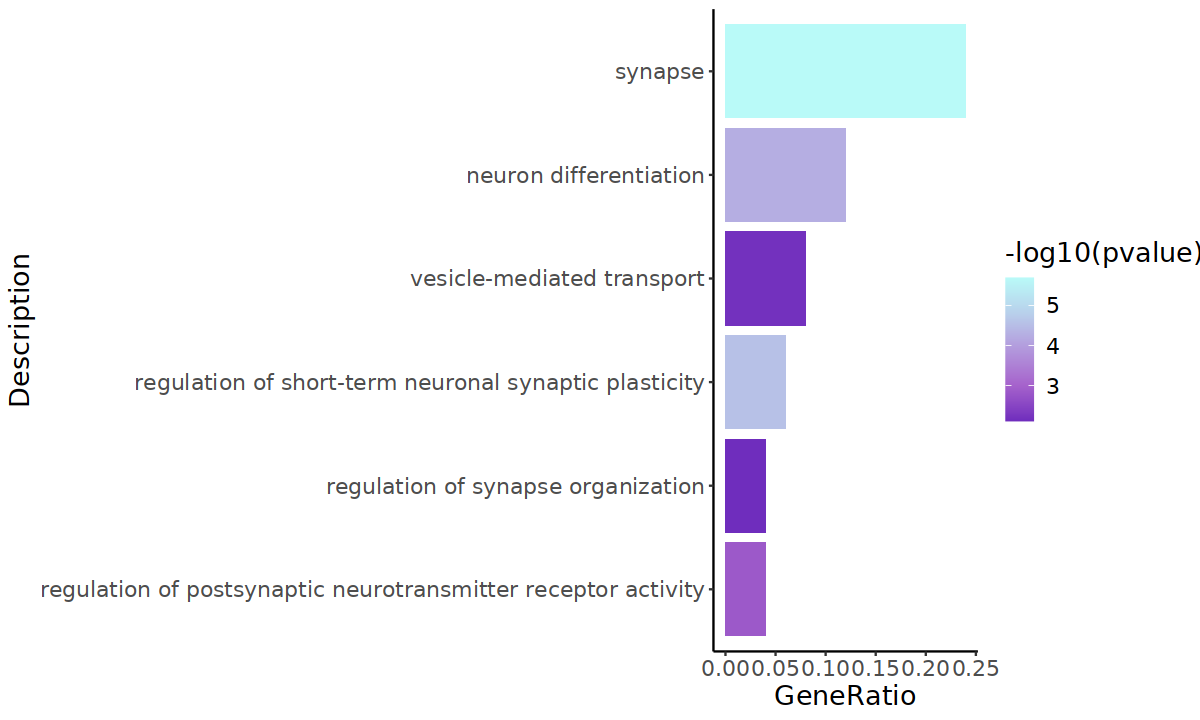

In [246]:
options(repr.plot.width=10,repr.plot.height=6)
p <- plot_GO_bar(MammalBird_GO,Description = c('synapse',
                                      'regulation of short-term neuronal synaptic plasticity',
                                      'neuron differentiation',
                                      'vesicle-mediated transport',
                                      'regulation of postsynaptic neurotransmitter receptor activity',
                                      'regulation of synapse organization'))+
scale_fill_gradientn(colours = c("#6f2dbd","#a663cc","#b298dc","#b8d0eb","#b9faf8"))
p
pdf(paste0('/mnt/gandan/huangzhi/jupyter/Multispecies/Plot/Association_related/MammalBird_GO_bar.pdf'),width=10,height=6)
p
dev.off()